# Análisis exploratorio y Modelo Predictivo: Online Retail II

**Objetivo**: Construir un modelo para predecir la probabilidad de que un cliente repita compra en la tienda.
Sigue las instrucciones proporcionadas.

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import xgboost as xgb

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

In [3]:
# Carga de datos 
DATA_PATH = r'online_retail_II.xlsx'
xl = pd.ExcelFile(DATA_PATH)
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Filas: 1,067,371 | Columnas: 8


## 2. Primera inspección

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


## 3. Calidad de datos (Limpieza)

In [6]:
# 1. Eliminar duplicados
print(f"Duplicados antes: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicados después: {df.duplicated().sum()}")

# 2. Valores nulos
print("\nNulos por columna:")
print(df.isnull().sum())
# Eliminamos registros sin Customer ID
df = df.dropna(subset=['Customer ID'])

# 3. Eliminar cancelaciones 
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# 4. Cantidad y precio positivos
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# 5. Calcular revenue
df['Revenue'] = df['Quantity'] * df['Price']
print(f"\nFilas finales tras limpieza: {len(df):,}")

Duplicados antes: 34335
Duplicados después: 0

Nulos por columna:
Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64

Filas finales tras limpieza: 779,425


## 4. Estadísticas descriptivas y Visualizaciones

In [7]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,779425.000000,779425,779425.000000,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593476,3.218488,15320.360461,22.291823
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,145.855814,NaN,29.676140,1695.692775,227.427075


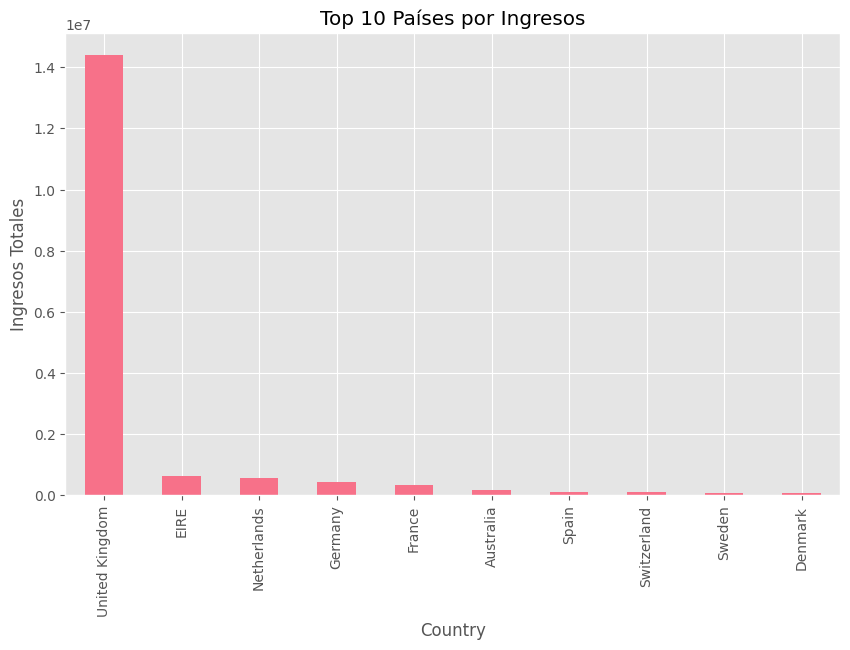

In [8]:
# Top 10 Países por ingresos
plt.figure(figsize=(10,6))
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Países por Ingresos')
plt.ylabel('Ingresos Totales')
plt.show()

## 5. Construcción de Variables (RFM) y Variable Objetivo

Estrategia de Modelado:
1. Definimos una fecha de corte (`cutoff_date`), por ejemplo, 6 meses antes de la fecha máxima del dataset.
2. Con los datos antes de la fecha de corte, generamos variables históricas por cliente (Recency, Frequency, Monetary).
3. Con los datos posteriores a la fecha de corte, vemos si el cliente compró (Target = 1) o no (Target = 0).

In [9]:
# El dataset va de dic 2009 a dic 2011.
print("Fecha mínima:", df['InvoiceDate'].min())
print("Fecha máxima:", df['InvoiceDate'].max())

# Usaremos los últimos 6 meses para la variable objetivo
cutoff_date = df['InvoiceDate'].max() - pd.DateOffset(months=6)

# Dividir dataset histórico y futuro
df_features = df[df['InvoiceDate'] < cutoff_date]
df_target = df[df['InvoiceDate'] >= cutoff_date]

print(f"Fecha de corte: {cutoff_date}")

Fecha mínima: 2009-12-01 07:45:00
Fecha máxima: 2011-12-09 12:50:00
Fecha de corte: 2011-06-09 12:50:00


In [10]:
# Generar características a nivel cliente
rfm = df_features.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (cutoff_date - x.max()).days, # Recency: días desde última compra
    'Invoice': 'nunique', # Frequency: nº de compras distintas
    'Revenue': 'sum', # Monetary: gasto total
    'Quantity': 'sum' # Cantidad de productos
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Revenue': 'Monetary',
    'Quantity': 'TotalItems'
})

rfm['Ticket_Medio'] = rfm['Monetary'] / rfm['Frequency']

# Generar variable objetivo (¿Compró en los últimos 6 meses?)
clientes_recompran = df_target['Customer ID'].unique()
rfm['Target'] = rfm.index.isin(clientes_recompran).astype(int)

print("Distribución de la variable objetivo:")
print(rfm['Target'].value_counts(normalize=True))
rfm.head()

Distribución de la variable objetivo:
Target
1    0.518824
0    0.481176
Name: proportion, dtype: float64


,Recency,Frequency,Monetary,TotalItems,Ticket_Medio,Target
Customer ID,,,,,,
12346.0,142,12,77556.46,74285,6463.038333,0
12347.0,63,4,2434.96,1626,608.740000,1
12348.0,65,4,1709.40,2497,427.350000,1
12349.0,224,3,2671.14,993,890.380000,1
12350.0,126,1,334.40,197,334.400000,0


## 6. Tratamiento de Outliers (en características RFM)

In [11]:
# Eliminar outliers extremos en Monetary o Frequency usando percentiles
p99_monetary = rfm['Monetary'].quantile(0.99)
p99_freq = rfm['Frequency'].quantile(0.99)

print(f"Clientes antes de limpiar outliers: {len(rfm)}")
rfm = rfm[(rfm['Monetary'] <= p99_monetary) & (rfm['Frequency'] <= p99_freq)]
print(f"Clientes tras limpiar outliers: {len(rfm)}")

Clientes antes de limpiar outliers: 4967
Clientes tras limpiar outliers: 4897


## 7. Modelado

In [12]:
# Separar variables predictoras y variable objetivo
X = rfm.drop('Target', axis=1)
y = rfm['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")

Tamaño del set de entrenamiento: (3917, 5)
Tamaño del set de prueba: (980, 5)


In [13]:
# Modelo 1: Regresión Logística
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
lr_pred_prob = lr.predict_proba(X_test)[:, 1]
print("AUC Regresión Logística:", roc_auc_score(y_test, lr_pred_prob))

# Modelo 2: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred_prob = rf.predict_proba(X_test)[:, 1]
print("AUC Random Forest:", roc_auc_score(y_test, rf_pred_prob))

# Modelo 3: XGBoost
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
print("AUC XGBoost:", roc_auc_score(y_test, xgb_pred_prob))

AUC Regresión Logística: 0.7982086516540172
AUC Random Forest: 0.7780966194447569
AUC XGBoost: 0.7786884562645093


## 8. Optimización de hiperparámetros

In [14]:
# Optimizaremos el modelo Random Forest como ejemplo
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rs = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_dist, n_iter=15, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
rs.fit(X_train, y_train)

best_model = rs.best_estimator_
print("Mejores hiperparámetros:", rs.best_params_)

best_pred_prob = best_model.predict_proba(X_test)[:, 1]
print("Mejor AUC Random Forest Tras Optimización:", roc_auc_score(y_test, best_pred_prob))

Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 5}
Mejor AUC Random Forest Tras Optimización: 0.8172620461716076


## 9. Resultados y Explicabilidad

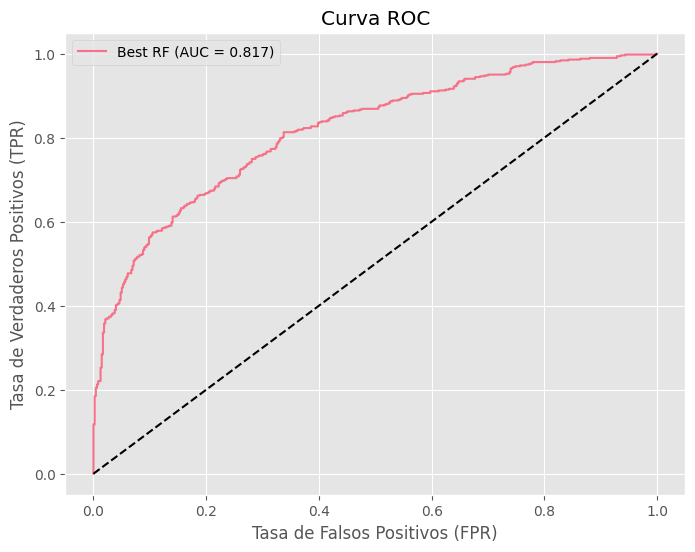

In [15]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, best_pred_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Best RF (AUC = {roc_auc_score(y_test, best_pred_prob):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

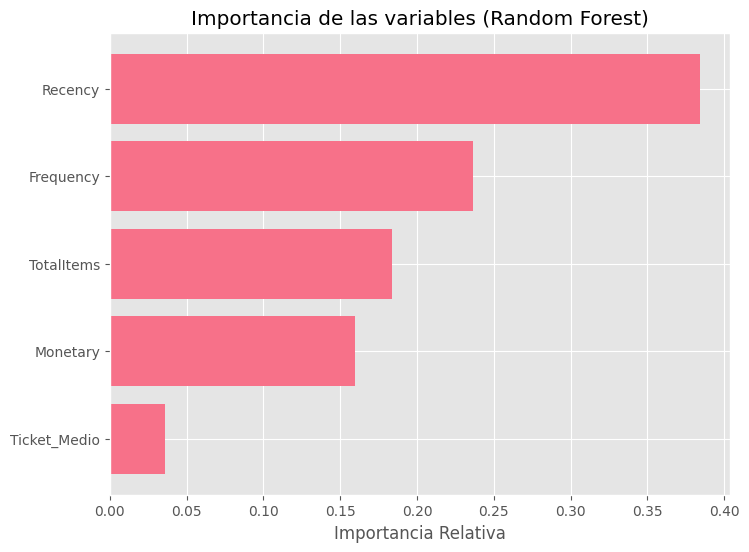

In [16]:
# Importancia de variables
importances = best_model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.title('Importancia de las variables (Random Forest)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.show()